In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import numpy as np
import subprocess
import sys

import os



import seaborn as sns
from sklearn.metrics import precision_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeRegressor, plot_tree, _tree
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import math
import scipy.cluster as sc
import scipy.spatial.distance as sd
from tqdm.auto import tqdm

In [ ]:
def installPackage(package):
    try:
        subprocess.check_call([sys.executable, '-m', 'conda', 'install', package, '-y'])
    except subprocess.CalledProcessError as e:
        print(f'Error installing {package}: {e}')

def checkAndinstallPackages():
    required = [
        'pandas', 'matplotlib','numpy',
        'seaborn', 'scikit-learn', 'scipy',
        'math', 'tqdm'
    ]

    for package in tqdm(required, desc='Checking and Installing Packages', unit='package'):
        try:
            __import__(package)
            print(f'{package} is already installed')
        except ImportError:
            print(f'{package} not found, installing')
            subprocess.check_call([sys.executable, "-m", "conda", "install", package, "-y"])

checkAndinstallPackages()

In [56]:
filePath = 'Top10VideoGameStocks.csv'
vG = pd.read_csv(filePath, sep=',')
vG.head(5)

,Date,Company,Ticker Symbol,Currency,Open,High,Low,Close,Adj Close,Volume
0,2000-01-01,Sony Interactive Entertainment,SONY,JPY,28.525000,29.168751,20.850000,25.299999,14.535083,147012000
1,2000-02-01,Sony Interactive Entertainment,SONY,JPY,25.293751,31.475000,25.000000,31.350000,18.010864,67437000
2,2000-03-01,Sony Interactive Entertainment,SONY,JPY,30.100000,31.299999,21.700001,28.012501,16.093437,112674000
3,2000-04-01,Sony Interactive Entertainment,SONY,JPY,28.250000,28.250000,22.312500,22.562500,12.974537,74071000
4,2000-05-01,Sony Interactive Entertainment,SONY,JPY,22.700001,23.481251,17.750000,18.237499,10.487453,65035500


In [57]:
vG= vG.rename(columns={'Ticker Symbol': 'Ticker_Symbol', 'Adj Close': 'Adj_Close'})
print(vG['Ticker_Symbol'].unique())

['SONY' '0700.HK' 'MSFT' 'NTDOY' 'NTES' 'EA' 'TTWO' 'EMBRAC-B.ST' 'RBLX'
 'PLTK']


In [58]:
companyTickers = ['SONY', '0700.HK', 'MSFT', 'NTDOY', 'NTES', 'EA', 'TTWO',
       'EMBRAC-B.ST', 'RBLX', 'PLTK']

def filterByCompany(filePath, TickerName):
    df = filePath
    if TickerName not in companyTickers:
        print(f"Company Ticker '{companyTickers}' is not in the list of valid Company Tickers.")
        return None
    filteredData = df[df['Ticker_Symbol'] == TickerName]
    dictName = TickerName.replace(" ", "_") + "_filtered"
    globals()[dictName] = filteredData

    return filteredData

TickerName = 'SONY'
filteredData = filterByCompany(vG, TickerName)



In [59]:
SONY_filtered = SONY_filtered.set_index('Date')
SONY_filtered

,Company,Ticker_Symbol,Currency,Open,High,Low,Close,Adj_Close,Volume
Date,,,,,,,,,
2000-01-01,Sony Interactive Entertainment,SONY,JPY,28.525000,29.168751,20.850000,25.299999,14.535083,147012000
2000-02-01,Sony Interactive Entertainment,SONY,JPY,25.293751,31.475000,25.000000,31.350000,18.010864,67437000
2000-03-01,Sony Interactive Entertainment,SONY,JPY,30.100000,31.299999,21.700001,28.012501,16.093437,112674000
2000-04-01,Sony Interactive Entertainment,SONY,JPY,28.250000,28.250000,22.312500,22.562500,12.974537,74071000
2000-05-01,Sony Interactive Entertainment,SONY,JPY,22.700001,23.481251,17.750000,18.237499,10.487453,65035500
...,...,...,...,...,...,...,...,...,...
2024-06-01,Sony Interactive Entertainment,SONY,JPY,16.625999,17.497999,15.860000,16.990000,16.990000,83581000
2024-07-01,Sony Interactive Entertainment,SONY,JPY,17.024000,19.294001,17.004000,17.718000,17.718000,90385000
2024-08-01,Sony Interactive Entertainment,SONY,JPY,17.346001,19.544001,15.956000,19.511999,19.511999,90948500


<Axes: xlabel='Date'>

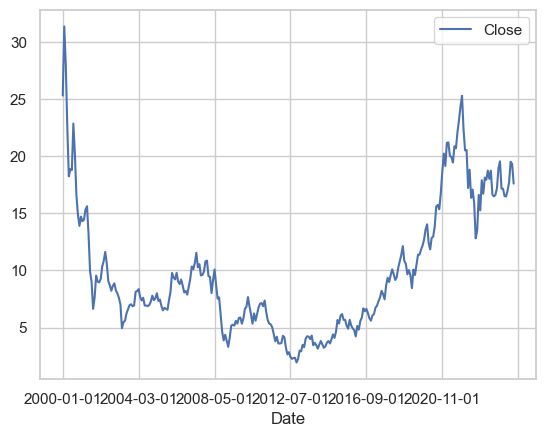

In [60]:
SONY_filtered.plot(y='Close', use_index='True')

In [61]:
SONY_filtered['Tomorrow'] = SONY_filtered['Close'].shift(-1)
SONY_filtered['Target'] = (SONY_filtered['Tomorrow'] > SONY_filtered['Close']).astype(int) # is tomorrows price greater than today

In [62]:
model = RandomForestClassifier(n_estimators=700, min_samples_split=14, max_depth = 10, random_state=31)

train= SONY_filtered.iloc[:-60]
test= SONY_filtered.iloc[-238:]

predictors = ['Close', 'Volume', 'High', 'Low']
target = 'Target'
model.fit(train[predictors], train['Target'])

predictions = model.predict(test[predictors])
predictions = pd.Series(predictions, index=test.index)
accuracy = accuracy_score(test[target], predictions)
print(f'Accuracy: {accuracy}')

precision = precision_score(test['Target'], predictions)
print(f'Precision Score: {precision}')

tree = model.estimators_[0]

def getMaxDepth(tree):
    return tree.tree_.max_depth



Accuracy: 0.7899159663865546
Precision Score: 0.8407079646017699


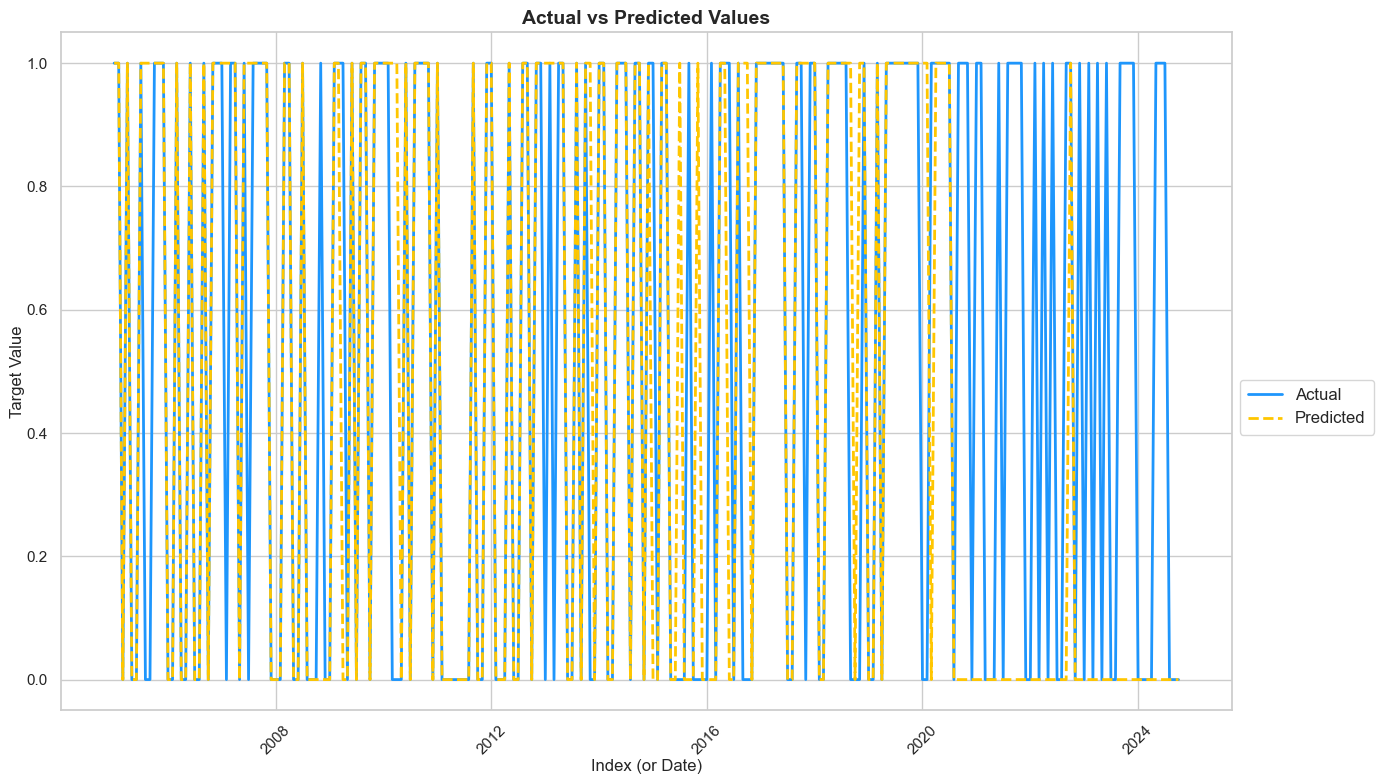

In [51]:
combinedValues = pd.concat([test['Target'], predictions], axis=1)
combinedValues.columns = ['Actual', 'Predicted'] 
combinedValues.index = pd.to_datetime(combinedValues.index)

sns.set(style="whitegrid")
plt.figure(figsize=(14, 8))

plt.plot(combinedValues.index, combinedValues['Actual'], label='Actual', color='#1E96FC', linewidth=2)
plt.plot(combinedValues.index, combinedValues['Predicted'], label='Predicted', color='#FFC600', linewidth=2, linestyle='--')

plt.xlabel('Index (or Date)', fontsize=12, labelpad=1)
plt.ylabel('Target Value', fontsize=12, labelpad=1)
plt.title('Actual vs Predicted Values',weight='bold', fontsize=14)
plt.legend(fontsize=12, bbox_to_anchor=(1,0.5), borderpad=.5)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

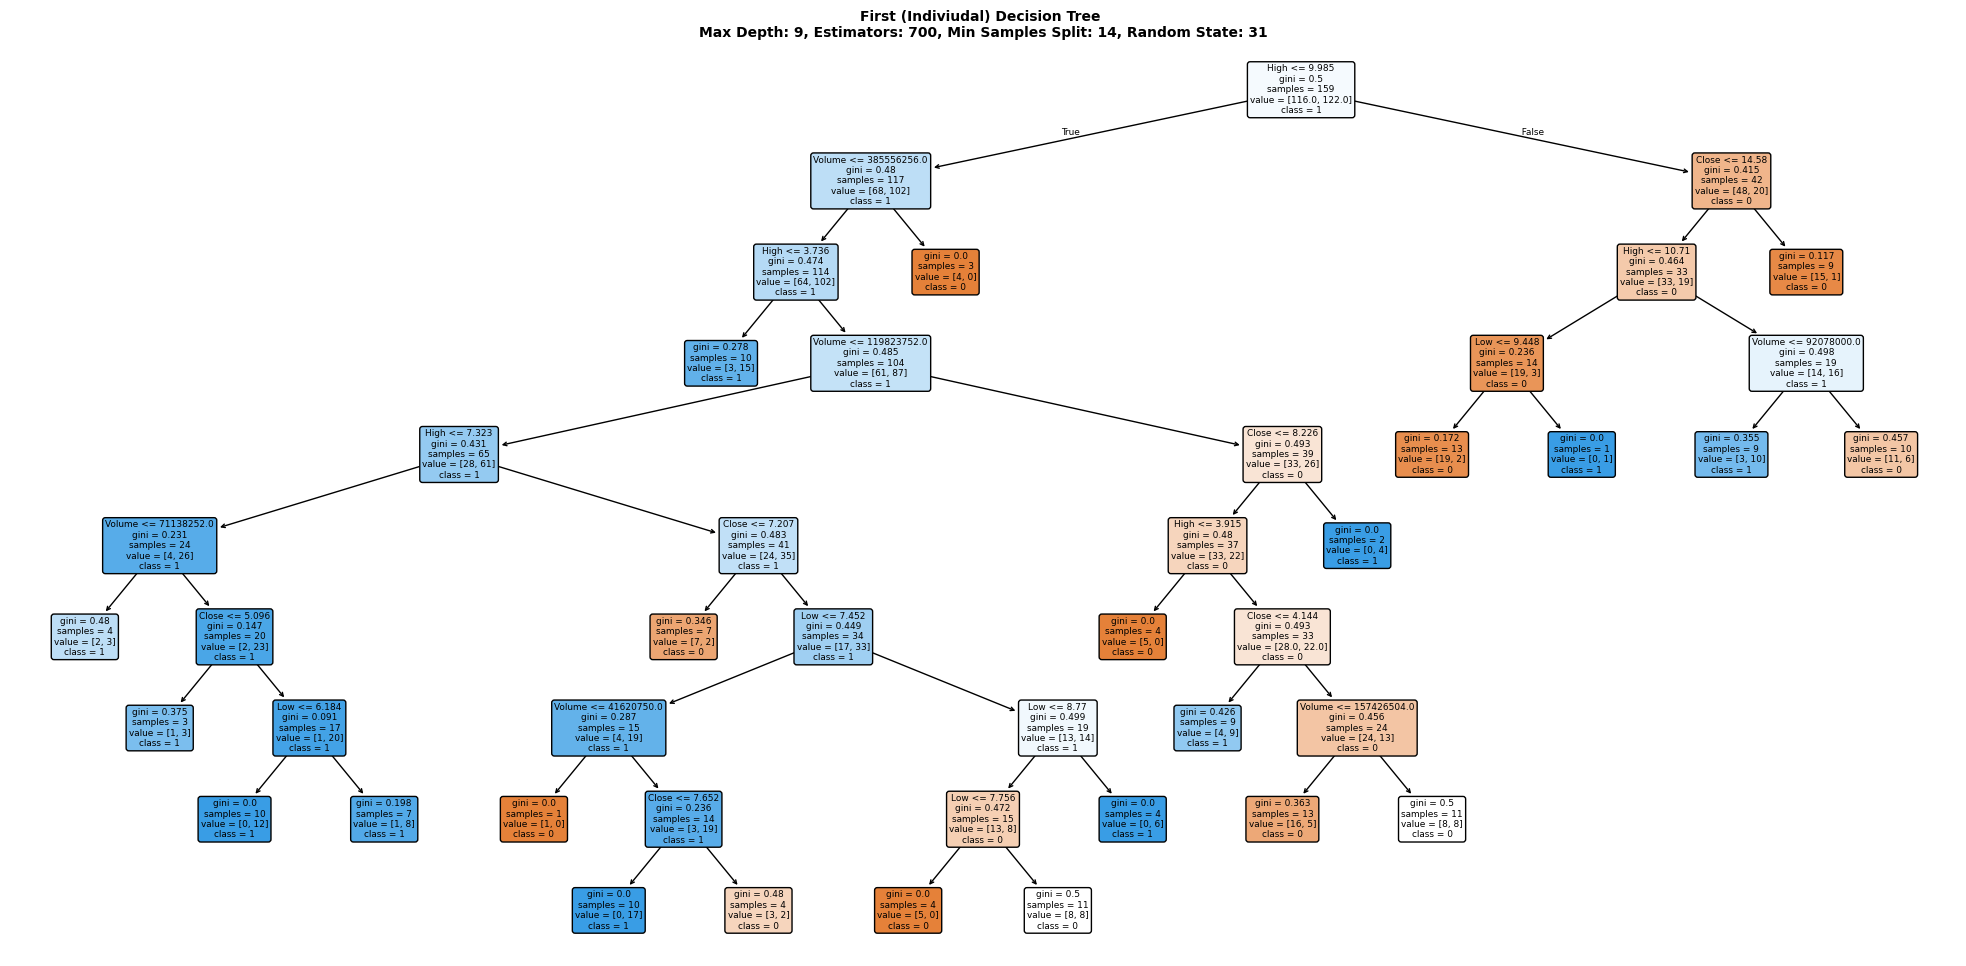

<Figure size 640x480 with 0 Axes>

In [19]:
max_depth = getMaxDepth(tree)

title = f'First (Indiviudal) Decision Tree \nMax Depth: {max_depth}, Estimators: {model.n_estimators}, Min Samples Split: {model.min_samples_split}, Random State: {model.random_state}'

sns.set_context("notebook", font_scale=1.5)  
plt.figure(figsize=(20, 10))  
plot_tree(model.estimators_[0], 
          filled=True, 
          feature_names=predictors, 
          class_names=model.classes_.astype(str), 
          rounded=True)
plt.title(title, fontsize=10, weight='bold', pad=5)
plt.tight_layout()
plt.show()
plt.savefig('First Decision Tree for SONY.png', dpi=300)

In [82]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train['Target'])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name='Predictions')
    combinedVals = pd.concat([test['Target'], preds], axis=1)
    return combinedVals

def backtest(data, model, predictors):
    allPredictions = []  
    
    for i in tqdm(range(len(data) - 60), desc="Backtesting Progress", unit="iteration"): 
        train = data.iloc[:i+60] 
        test = data.iloc[i+60:i+61]  
        
        predictions = predict(train, test, predictors, model)
        if predictions is not None and not predictions.empty:
            allPredictions.append(predictions)  # Append valid predictions
        else:
            print(f"Skipping prediction for index {i}, no valid predictions.")
    
    if not allPredictions:
        print("No predictions generated. Returning empty DataFrame.")
        return pd.DataFrame()  
    
    return pd.concat(allPredictions)


In [ ]:
predictions = backtest(SONY_filtered, model, predictors)

Backtesting Progress:   0%|          | 0/238 [00:00<?, ?iteration/s]